# ================================================
# EDA PART 1: Data Structure Understanding
# ================================================
# Purpose:
#   - Define what kind of segmentation problem this dataset represents
#   - Analyze class-level structure and anatomical constraints

**[Cell 1] Imports & basic setup**

In [6]:
import os
import json
import numpy as np
import pandas as pd
import cv2
import matplotlib.pyplot as plt
from collections import Counter
from tqdm import tqdm

IMAGE_ROOT = "/data/ephemeral/home/data/train/DCM"
LABEL_ROOT = "/data/ephemeral/home/data/train/outputs_json"

CLASSES = [
    'finger-1','finger-2','finger-3','finger-4','finger-5',
    'finger-6','finger-7','finger-8','finger-9','finger-10',
    'finger-11','finger-12','finger-13','finger-14','finger-15',
    'finger-16','finger-17','finger-18','finger-19',
    'Trapezium','Trapezoid','Capitate','Hamate',
    'Scaphoid','Lunate','Triquetrum','Pisiform',
    'Radius','Ulna'
]

CLASS2IND = {c: i for i, c in enumerate(CLASSES)}

**[Cell 2] Load image / label pairs**

In [7]:
images, labels = [], []

for root, _, files in os.walk(IMAGE_ROOT):
    for f in files:
        if f.endswith(".png"):
            rel = os.path.relpath(os.path.join(root, f), IMAGE_ROOT)
            images.append(rel)
            labels.append(rel.replace(".png", ".json"))

images = sorted(images)
labels = sorted(labels)

print(f"Total images: {len(images)}")

Total images: 800


**[Cell 3] Image-level class presence (#classes per image)**

100%|██████████| 800/800 [00:03<00:00, 234.77it/s]


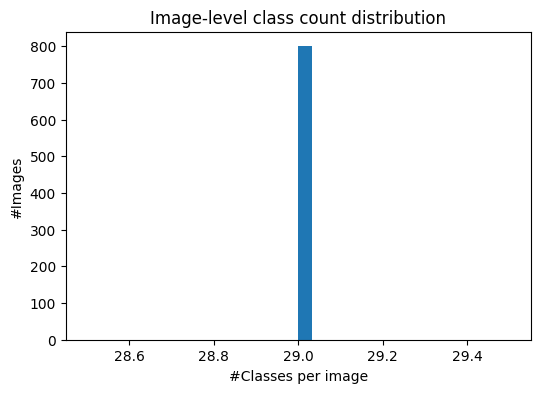

In [8]:
image_class_counts = []
class_presence = Counter()

for lb in tqdm(labels):
    with open(os.path.join(LABEL_ROOT, lb)) as f:
        anns = json.load(f)["annotations"]

    present_classes = set(a["label"] for a in anns)
    image_class_counts.append(len(present_classes))

    for c in present_classes:
        class_presence[c] += 1

plt.figure(figsize=(6, 4))
plt.hist(image_class_counts, bins=30)
plt.xlabel("#Classes per image")
plt.ylabel("#Images")
plt.title("Image-level class count distribution")
plt.show()

**[Cell 4] Class appearance frequency (structural imbalance)**

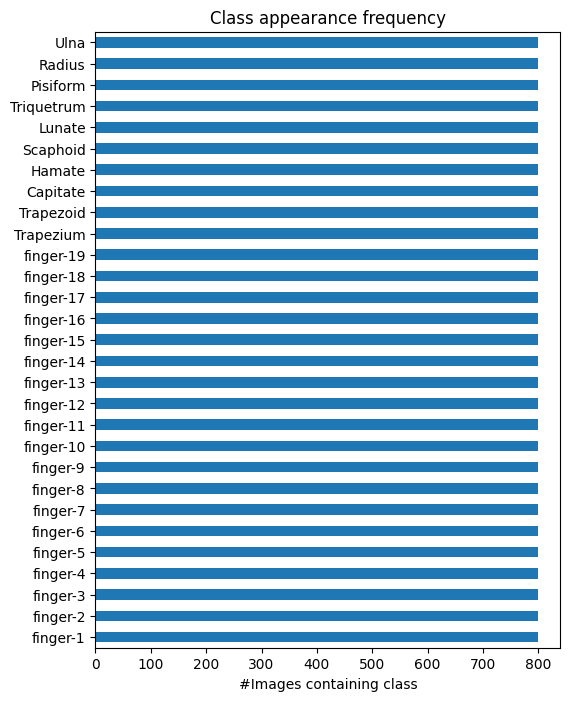

In [9]:
freq = pd.Series(class_presence).reindex(CLASSES)

plt.figure(figsize=(6, 8))
freq.sort_values().plot(kind="barh")
plt.xlabel("#Images containing class")
plt.title("Class appearance frequency")
plt.show()

**[Cell 5] Zero-mask ratio per class**

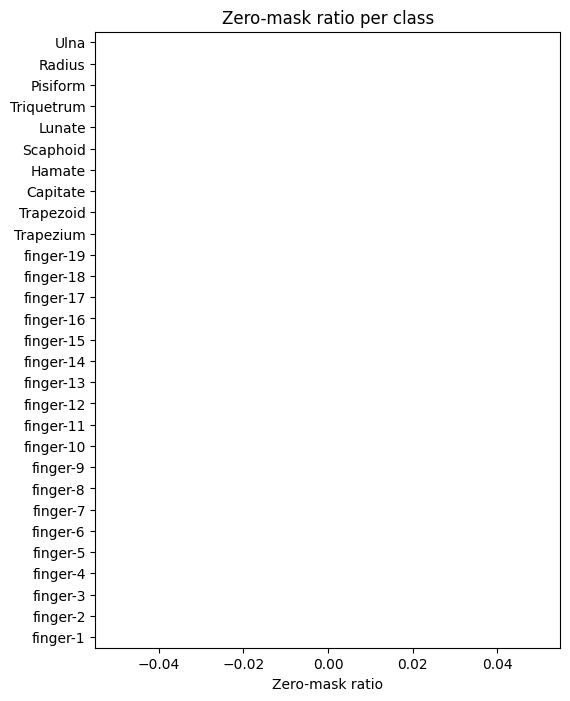

In [10]:
zero_mask_ratio = {
    c: 1.0 - (class_presence[c] / len(images))
    for c in CLASSES
}

zero_mask_ratio = pd.Series(zero_mask_ratio)

plt.figure(figsize=(6, 8))
zero_mask_ratio.sort_values().plot(kind="barh")
plt.xlabel("Zero-mask ratio")
plt.title("Zero-mask ratio per class")
plt.show()

**[Cell 6] Class co-occurrence matrix**

100%|██████████| 800/800 [00:03<00:00, 206.20it/s]


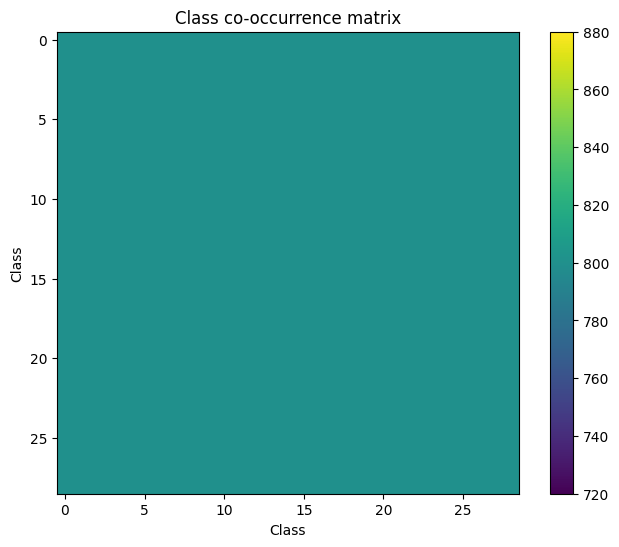

In [11]:
co_occurrence = np.zeros((len(CLASSES), len(CLASSES)), dtype=int)

for lb in tqdm(labels):
    with open(os.path.join(LABEL_ROOT, lb)) as f:
        anns = json.load(f)["annotations"]

    present = [a["label"] for a in anns]

    for c1 in present:
        for c2 in present:
            co_occurrence[CLASS2IND[c1], CLASS2IND[c2]] += 1

plt.figure(figsize=(8, 6))
plt.imshow(co_occurrence)
plt.colorbar()
plt.title("Class co-occurrence matrix")
plt.xlabel("Class")
plt.ylabel("Class")
plt.show()

**[Cell 7] Sample image visualization**

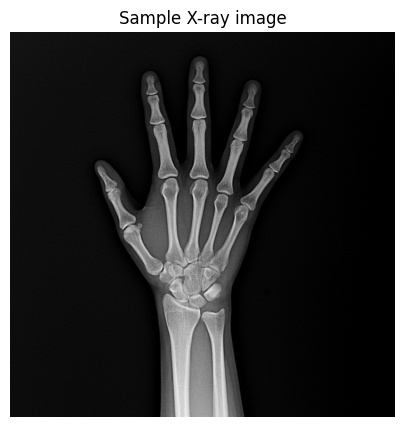

In [12]:
sample_img = images[0]
img = cv2.imread(os.path.join(IMAGE_ROOT, sample_img))
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(5, 5))
plt.imshow(img)
plt.axis("off")
plt.title("Sample X-ray image")
plt.show()